# NYC Robustness Checks and Boston External-Control Stress Test

This notebook formalizes two robustness exercises for the Manhattan congestion-pricing bus-speed analysis.

1. **NYC treatment-definition robustness**: compare the main GeoJSON any-intersection treatment against stricter CBD share thresholds and the old official CBD-source union.
2. **Boston external-control stress test**: compare NYC CBD-exposed routes against MBTA Boston routes using the processed Boston monthly speed panel.

The Boston exercise is a robustness/stress test, not the preferred identification design. The agencies, route networks, and raw speed construction differ, so Boston is best interpreted as an external benchmark unless later diagnostics support a stronger design.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

NYC_PANEL = PROCESSED / "nyc_did_panel_geojson_intersection.csv"
NYC_ROBUSTNESS = TABLES / "nyc_treatment_definition_robustness.csv"
BOSTON_PANEL = PROCESSED / "boston_bus_speeds_monthly.csv"
BOSTON_COMPARISON_OUTPUT = TABLES / "nyc_vs_boston_external_control_robustness.csv"

POLICY_MONTH = pd.Timestamp("2025-01-01")
ANALYSIS_START = pd.Timestamp("2023-08-01")
ANALYSIS_END = pd.Timestamp("2026-05-01")

pd.set_option("display.max_columns", 80)
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

## 1. NYC Treatment-Definition Robustness

The main treatment definition is `cbd_route = True` when any retained GeoJSON route shape intersects the CBD geofence. Threshold definitions are stricter robustness checks based on the maximum route-shape share inside the CBD.

In [2]:
robustness = pd.read_csv(NYC_ROBUSTNESS)
robustness.head(10)

,sample,treatment_column,treatment_definition,independent_treatment_check,estimate_mph,std_error,p_value,ci_low,ci_high,rows,routes,treated_routes
0,weekday_all_periods,any_intersection,GeoJSON any policy-date route shape intersects...,True,0.156415,0.047743,0.001052,0.062839,0.249992,19108,301,84
1,weekday_all_periods,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,True,0.157395,0.048734,0.001239,0.061876,0.252913,19108,301,82
2,weekday_all_periods,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,True,0.156093,0.049429,0.001589,0.059212,0.252973,19108,301,77
3,weekday_all_periods,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,True,0.059858,0.072741,0.410570,-0.082715,0.202432,19108,301,33
4,weekday_all_periods,max_share_ge_50pct,GeoJSON max shape share in CBD >= 50%,True,0.012146,0.024082,0.614021,-0.035055,0.059346,19108,301,22
5,weekday_all_periods,max_share_ge_80pct,GeoJSON max shape share in CBD >= 80%,True,0.026235,0.026399,0.320332,-0.025508,0.077978,19108,301,15
6,weekday_all_periods,old_official_source_union,Old official CBD route/speed source union,False,0.156415,0.047743,0.001052,0.062839,0.249992,19108,301,84
7,all_day_types_all_periods,any_intersection,GeoJSON any policy-date route shape intersects...,True,0.145735,0.044526,0.001064,0.058464,0.233006,36077,305,84
8,all_day_types_all_periods,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,True,0.148872,0.045561,0.001085,0.059572,0.238173,36077,305,82
9,all_day_types_all_periods,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,True,0.153570,0.045418,0.000722,0.064550,0.242589,36077,305,77


In [3]:
weekday = robustness[robustness["sample"].eq("weekday_all_periods")].copy()
weekday["estimate_label"] = weekday["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
    "old_official_source_union": "Old official union",
})
weekday[["estimate_label", "treated_routes", "estimate_mph", "std_error", "p_value", "ci_low", "ci_high"]]

,estimate_label,treated_routes,estimate_mph,std_error,p_value,ci_low,ci_high
0,Any intersection,84,0.156415,0.047743,0.001052,0.062839,0.249992
1,>= 5% max share,82,0.157395,0.048734,0.001239,0.061876,0.252913
2,>= 10% max share,77,0.156093,0.049429,0.001589,0.059212,0.252973
3,>= 25% max share,33,0.059858,0.072741,0.410570,-0.082715,0.202432
4,>= 50% max share,22,0.012146,0.024082,0.614021,-0.035055,0.059346
5,>= 80% max share,15,0.026235,0.026399,0.320332,-0.025508,0.077978
6,Old official union,84,0.156415,0.047743,0.001052,0.062839,0.249992


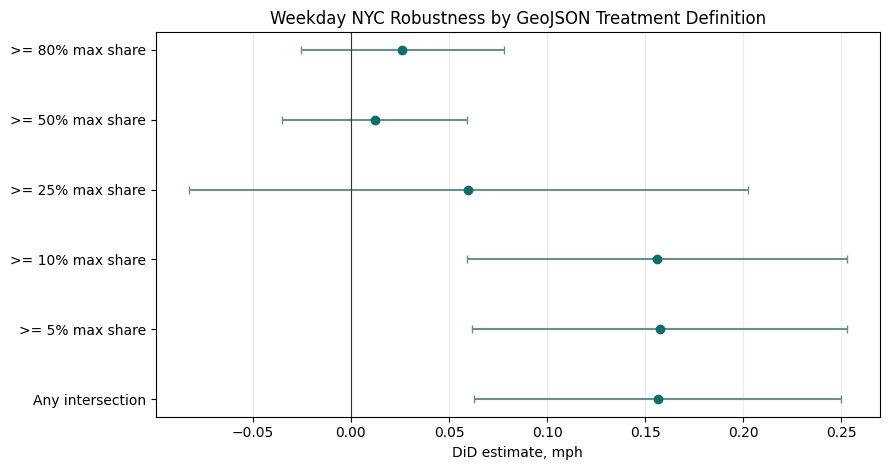

In [4]:
plot_df = weekday[weekday["treatment_column"].ne("old_official_source_union")].copy()
plot_df = plot_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(plot_df))
ax.errorbar(
    plot_df["estimate_mph"],
    y,
    xerr=[plot_df["estimate_mph"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["estimate_mph"]],
    fmt="o",
    color="#0b6e69",
    ecolor="#6b8f8b",
    capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["estimate_label"])
ax.set_xlabel("DiD estimate, mph")
ax.set_title("Weekday NYC Robustness by GeoJSON Treatment Definition")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

**Takeaway.** The main estimate is stable under small CBD-share thresholds (`>= 5%` and `>= 10%`). It attenuates under stricter definitions that keep only routes with a large share inside the CBD. That pattern is consistent with the main treatment capturing crossing/exposed routes, not only routes that spend most of their shape length inside the CBD.

In [5]:
sample_summary = robustness.pivot_table(
    index="treatment_column",
    columns="sample",
    values="estimate_mph",
    aggfunc="first",
)
sample_summary

sample,all_day_types_all_periods,weekday_all_periods,weekday_off_peak,weekday_peak
treatment_column,,,,
any_intersection,0.145735,0.156415,0.130337,0.186601
max_share_ge_05pct,0.148872,0.157395,0.131672,0.187338
max_share_ge_10pct,0.153570,0.156093,0.128904,0.187792
max_share_ge_25pct,0.100931,0.059858,0.051737,0.066004
max_share_ge_50pct,0.052126,0.012146,0.023648,-0.001257
max_share_ge_80pct,0.072850,0.026235,0.044999,0.005622
old_official_source_union,0.145735,0.156415,0.130337,0.186601


## 2. Boston External-Control Stress Test

This section asks whether the NYC CBD speed gain is still visible when the comparison group is Boston MBTA bus routes rather than NYC non-CBD routes.

Construction choices:

- NYC sample: CBD-treated NYC routes only, weekday rows, August 2023 through May 2026.
- Boston sample: all processed MBTA routes, weekday rows, same months.
- Unit of observation: route-month-period after aggregating duplicate rows within each route/month/period.
- Model: `average_speed ~ did + route fixed effects + month fixed effects + period fixed effects`, clustered by route/unit.

This is deliberately labeled a stress test because Boston is an external city with different measurement and network structure.

In [6]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")


def build_nyc_cbd_external_panel():
    nyc = pd.read_csv(NYC_PANEL)
    nyc["month"] = pd.to_datetime(nyc["month"])
    nyc = nyc[
        nyc["month"].between(ANALYSIS_START, ANALYSIS_END)
        & nyc["day_type"].astype(str).eq("1")
        & nyc["cbd_route"].astype(bool)
    ].copy()
    nyc["total_mileage"] = clean_numeric(nyc["total_mileage"])
    nyc["total_operating_time"] = clean_numeric(nyc["total_operating_time"])
    grouped = (
        nyc.groupby(["month", "route_id", "period"], as_index=False)
        .agg(
            total_distance_miles=("total_mileage", "sum"),
            total_runtime_hours=("total_operating_time", "sum"),
        )
    )
    grouped["average_speed"] = grouped["total_distance_miles"] / grouped["total_runtime_hours"]
    grouped["unit_id"] = "NYC_CBD_" + grouped["route_id"].astype(str)
    grouped["city_group"] = "NYC CBD routes"
    grouped["treated"] = True
    grouped["post"] = grouped["month"].ge(POLICY_MONTH)
    return grouped


def build_boston_external_panel():
    boston = pd.read_csv(BOSTON_PANEL)
    boston["month"] = pd.to_datetime(boston["month"])
    boston = boston[
        boston["month"].between(ANALYSIS_START, ANALYSIS_END)
        & boston["day_type"].eq("Weekday")
    ].copy()
    grouped = (
        boston.groupby(["month", "route_id", "period"], as_index=False)
        .agg(
            total_distance_miles=("total_distance_miles", "sum"),
            total_runtime_hours=("total_runtime_hours", "sum"),
        )
    )
    grouped["average_speed"] = grouped["total_distance_miles"] / grouped["total_runtime_hours"]
    grouped["unit_id"] = "BOSTON_" + grouped["route_id"].astype(str)
    grouped["city_group"] = "Boston routes"
    grouped["treated"] = False
    grouped["post"] = grouped["month"].ge(POLICY_MONTH)
    return grouped

nyc_external = build_nyc_cbd_external_panel()
boston_external = build_boston_external_panel()
external_panel = pd.concat([nyc_external, boston_external], ignore_index=True)
external_panel = external_panel.dropna(subset=["average_speed", "total_runtime_hours"])
external_panel["did"] = external_panel["treated"].astype(int) * external_panel["post"].astype(int)

external_panel.groupby("city_group").agg(
    rows=("average_speed", "size"),
    routes=("unit_id", "nunique"),
    months=("month", "nunique"),
    mean_speed=("average_speed", "mean"),
    total_distance_miles=("total_distance_miles", "sum"),
)

,rows,routes,months,mean_speed,total_distance_miles
city_group,,,,,
Boston routes,9253,143,34,11.889809,3.832088e+07
NYC CBD routes,5585,84,34,9.516055,3.990156e+07


In [7]:
external_model = smf.ols(
    "average_speed ~ did + C(unit_id) + C(month) + C(period)",
    data=external_panel,
).fit(cov_type="cluster", cov_kwds={"groups": external_panel["unit_id"]})

external_result = pd.DataFrame([
    {
        "comparison": "NYC CBD routes vs Boston routes",
        "sample": "weekday_all_periods",
        "estimate_mph": external_model.params["did"],
        "std_error": external_model.bse["did"],
        "p_value": external_model.pvalues["did"],
        "ci_low": external_model.params["did"] - 1.96 * external_model.bse["did"],
        "ci_high": external_model.params["did"] + 1.96 * external_model.bse["did"],
        "rows": len(external_panel),
        "units": external_panel["unit_id"].nunique(),
        "nyc_cbd_units": nyc_external["unit_id"].nunique(),
        "boston_units": boston_external["unit_id"].nunique(),
    }
])
external_result.to_csv(BOSTON_COMPARISON_OUTPUT, index=False)
external_result

,comparison,sample,estimate_mph,std_error,p_value,ci_low,ci_high,rows,units,nyc_cbd_units,boston_units
0,NYC CBD routes vs Boston routes,weekday_all_periods,0.477442,0.062084,1.468977e-14,0.355757,0.599128,14838,227,84,143


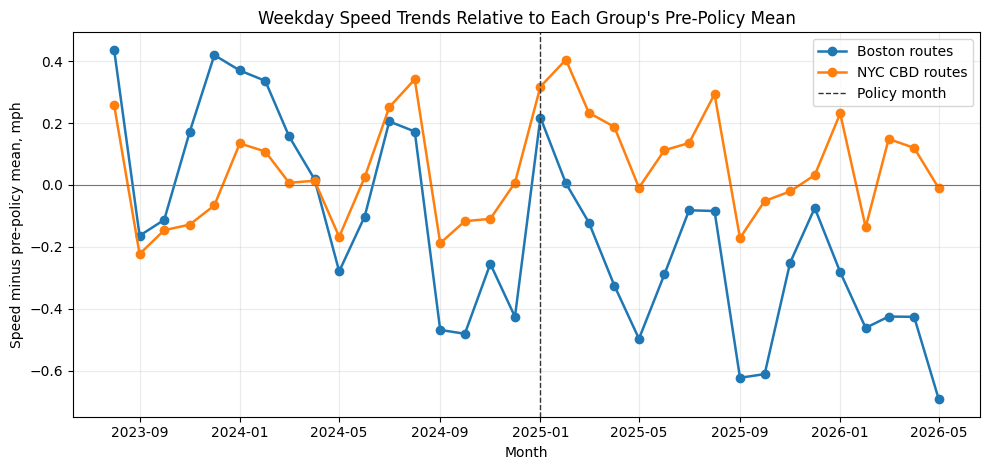

In [8]:
trend = (
    external_panel.groupby(["city_group", "month"], as_index=False)
    .agg(
        total_distance_miles=("total_distance_miles", "sum"),
        total_runtime_hours=("total_runtime_hours", "sum"),
    )
)
trend["average_speed"] = trend["total_distance_miles"] / trend["total_runtime_hours"]
pre_mean = trend[trend["month"].lt(POLICY_MONTH)].groupby("city_group")["average_speed"].mean()
trend["indexed_speed"] = trend.apply(lambda row: row["average_speed"] - pre_mean.loc[row["city_group"]], axis=1)

fig, ax = plt.subplots(figsize=(10, 4.8))
for group, group_df in trend.groupby("city_group"):
    ax.plot(group_df["month"], group_df["indexed_speed"], marker="o", linewidth=1.8, label=group)
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Weekday Speed Trends Relative to Each Group's Pre-Policy Mean")
ax.set_ylabel("Speed minus pre-policy mean, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Boston stress-test interpretation.** If the Boston comparison estimate has the same sign and broad magnitude as the main NYC control-route DiD, it gives some reassurance that the post-policy NYC CBD speed increase is not simply an artifact of using NYC non-CBD controls. If it differs sharply, that does not automatically invalidate the main design, because Boston is not a treated/control contrast within the same transit system.

In [9]:
print(f"Saved Boston external-control result to: {BOSTON_COMPARISON_OUTPUT.relative_to(ROOT)}")
print(f"Saved NYC threshold robustness table at: {NYC_ROBUSTNESS.relative_to(ROOT)}")

Saved Boston external-control result to: outputs\tables\nyc_vs_boston_external_control_robustness.csv
Saved NYC threshold robustness table at: outputs\tables\nyc_treatment_definition_robustness.csv


## Strict Peak and Off-Peak Treatment-Definition Robustness

The earlier results already compare the original GeoJSON treatment and CBD-share thresholds for weekday rows and for the combined all-day sample. The focused check below asks whether the same pattern appears when the service period is held strictly to Peak or strictly to Off-Peak weekday observations. Each row uses the same route fixed effects, month fixed effects, and route-clustered standard errors as the main DiD. The only changes are the sample restriction and the treatment definition.


In [10]:
strict_periods = robustness[robustness["sample"].isin(["weekday_peak", "weekday_off_peak"])].copy()
strict_periods["estimate_label"] = strict_periods["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
    "old_official_source_union": "Old official union",
})
strict_periods[["sample", "estimate_label", "treated_routes", "estimate_mph", "std_error", "p_value", "ci_low", "ci_high"]]


,sample,estimate_label,treated_routes,estimate_mph,std_error,p_value,ci_low,ci_high
14,weekday_peak,Any intersection,84,0.186601,0.046222,0.000054,0.096006,0.277197
15,weekday_peak,>= 5% max share,82,0.187338,0.047166,0.000071,0.094892,0.279783
16,weekday_peak,>= 10% max share,77,0.187792,0.047610,0.000080,0.094477,0.281107
17,weekday_peak,>= 25% max share,33,0.066004,0.066004,0.317314,-0.063365,0.195373
18,weekday_peak,>= 50% max share,22,-0.001257,0.024706,0.959433,-0.049680,0.047166
19,weekday_peak,>= 80% max share,15,0.005622,0.028060,0.841189,-0.049375,0.060619
20,weekday_peak,Old official union,84,0.186601,0.046222,0.000054,0.096006,0.277197
21,weekday_off_peak,Any intersection,84,0.130337,0.054364,0.016508,0.023784,0.236889
22,weekday_off_peak,>= 5% max share,82,0.131672,0.055520,0.017710,0.022853,0.240491
23,weekday_off_peak,>= 10% max share,77,0.128904,0.056822,0.023296,0.017532,0.240276


### Current run: strict-period conclusion

For the current panel, the any-intersection estimate is `+0.187 mph` in Peak service (`p < 0.001`) and `+0.130 mph` in Off-Peak service (`p = 0.017`). The 5% and 10% thresholds produce nearly identical positive estimates in both periods. At the 25%, 50%, and 80% thresholds, the estimates become smaller and are not statistically distinguishable from zero at conventional levels. Thus, the positive result is robust to Peak/Off-Peak sampling and modest thresholds, but not to definitions that retain only routes with very high CBD shape shares.
